# Othello-GPT Illegal Move Heatmap
## 125,717 Championship Games | 7,015,646 Positions | 1.91% Failure Rate

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle, Circle

# results from heatmap_experiment.py on full 125k dataset
count_board = np.array([
    [15781,  9050,  8137,  8750,  7931,  9834, 10007, 14218],
    [ 8807, 10966, 11488, 11020, 12718, 13616, 11669,  8402],
    [ 9189, 11645, 12013,  9974,  9632, 13295, 16163,  9895],
    [ 8395, 12966,  9819,     0,     0,  7126, 14197,  8398],
    [ 8769, 14865, 10807,     0,     0,  8102, 12563,  9382],
    [ 8329, 15151, 14368,  1309,    15,  9676, 14734,  9765],
    [ 9126, 11456, 16590, 14994, 10829, 15478, 11395,  8656],
    [16698,  9383, 10756, 10681, 10387,  9793,  8652, 14817],
])

prob_board = np.array([
    [577.3, 317.7, 252.4, 274.2, 246.5, 309.7, 352.1, 500.7],
    [296.9, 351.0, 351.3, 351.0, 426.8, 432.5, 376.1, 273.4],
    [290.0, 370.5, 414.0, 359.0, 347.3, 458.7, 529.4, 311.6],
    [264.1, 439.1, 347.7,   0.0,   0.0, 255.3, 502.7, 249.8],
    [277.7, 508.3, 412.8,   0.0,   0.0, 326.9, 437.3, 302.1],
    [256.3, 500.7, 547.1,  41.1,   0.3, 383.0, 490.1, 309.5],
    [312.1, 350.8, 566.3, 520.8, 381.8, 519.4, 352.8, 285.5],
    [615.3, 324.3, 352.7, 336.4, 334.6, 312.0, 295.1, 544.6],
])

cols = list('ABCDEFGH')
rows = [str(i) for i in range(1, 9)]

Matplotlib is building the font cache; this may take a moment.


## Illegal Prediction Counts
How many times each square was predicted illegally (>1% probability threshold)

/var/folders/2t/5pbb66gn4xqg1b4b1d638vnw0000gn/T/ipykernel_56186/1575220069.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap(cmap)


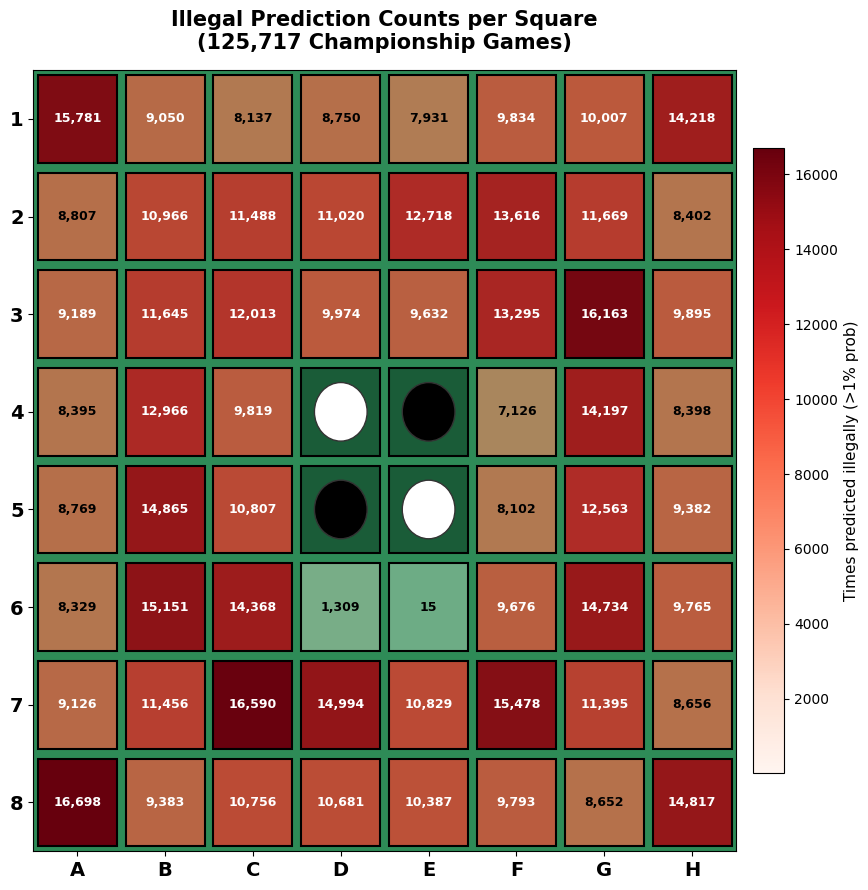

In [8]:
def draw_othello_heatmap(data, title, label, cmap='Reds'):
    fig, ax = plt.subplots(figsize=(9, 9))
    
    # green board background
    ax.set_facecolor('#2E8B57')
    
    # normalize data for color mapping (ignore zeros)
    nonzero = data[data > 0]
    vmin = nonzero.min() if len(nonzero) > 0 else 0
    vmax = nonzero.max()
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    colormap = plt.cm.get_cmap(cmap)
    
    for row in range(8):
        for col in range(8):
            val = data[row][col]
            
            # starting squares - draw with special marking
            if val == 0 and row in [3,4] and col in [3,4]:
                rect = Rectangle((col - 0.45, row - 0.45), 0.9, 0.9,
                                 facecolor='#1a5c38', edgecolor='black', linewidth=1.5)
                ax.add_patch(rect)
                # draw starting pieces
                piece_color = 'white' if (row + col) % 2 == 0 else 'black'
                circle = Circle((col, row), 0.3, facecolor=piece_color,
                                edgecolor='#333333', linewidth=1)
                ax.add_patch(circle)
                continue
            
            # color based on value
            if val > 0:
                rgba = colormap(norm(val))
                # blend with green: more red = more illegal predictions
                alpha = 0.3 + 0.7 * norm(val)  # 0.3 to 1.0 opacity
                blended = [
                    rgba[0] * alpha + (0.18) * (1 - alpha),
                    rgba[1] * alpha + (0.55) * (1 - alpha),
                    rgba[2] * alpha + (0.34) * (1 - alpha),
                ]
            else:
                blended = [0.18, 0.55, 0.34]
            
            rect = Rectangle((col - 0.45, row - 0.45), 0.9, 0.9,
                             facecolor=blended, edgecolor='black', linewidth=1.5)
            ax.add_patch(rect)
            
            # text label
            if val > 0:
                brightness = 0.299 * blended[0] + 0.587 * blended[1] + 0.114 * blended[2]
                text_color = 'white' if brightness < 0.5 else 'black'
                if val >= 1000:
                    txt = f"{int(val):,}"
                else:
                    txt = f"{val:.0f}"
                ax.text(col, row, txt, ha='center', va='center',
                        fontsize=9, fontweight='bold', color=text_color)
    
    # axis labels
    ax.set_xticks(range(8))
    ax.set_xticklabels(cols, fontsize=14, fontweight='bold')
    ax.set_yticks(range(8))
    ax.set_yticklabels(rows, fontsize=14, fontweight='bold')
    ax.set_xlim(-0.5, 7.5)
    ax.set_ylim(7.5, -0.5)
    ax.set_title(title, fontsize=15, fontweight='bold', pad=15)
    
    # colorbar
    sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label(label, fontsize=11)
    
    plt.tight_layout()
    return fig

fig = draw_othello_heatmap(
    count_board,
    'Illegal Prediction Counts per Square\n(125,717 Championship Games)',
    'Times predicted illegally (>1% prob)'
)
fig.savefig('heatmap_counts.png', dpi=200, bbox_inches='tight')
plt.show()

## Total Illegal Probability Assigned
Sum of all probability the model incorrectly assigned to each square across all positions

/var/folders/2t/5pbb66gn4xqg1b4b1d638vnw0000gn/T/ipykernel_56186/1575220069.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap(cmap)


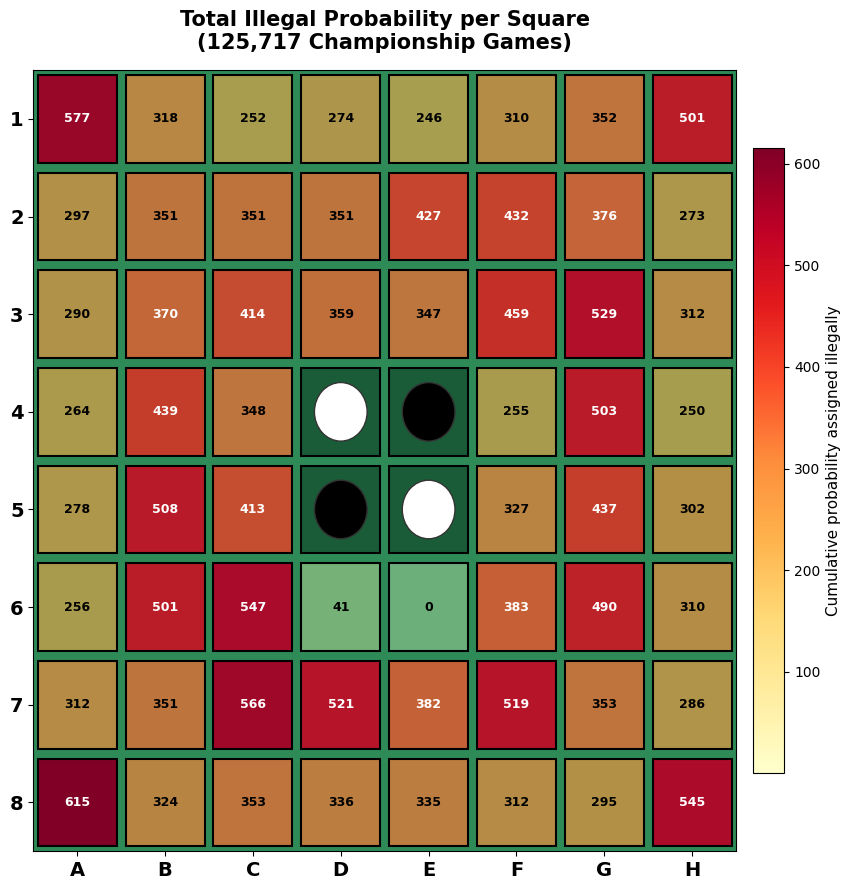

In [9]:
fig = draw_othello_heatmap(
    prob_board,
    'Total Illegal Probability per Square\n(125,717 Championship Games)',
    'Cumulative probability assigned illegally',
    cmap='YlOrRd'
)
fig.savefig('heatmap_probability.png', dpi=200, bbox_inches='tight')
plt.show()

## Top 10 Worst Squares

| Rank | Square | Count | Total Prob | Type |
|------|--------|-------|------------|------|
| 1 | A8 | 16,698 | 615.3 | Corner |
| 2 | C7 | 16,590 | 566.3 | Center |
| 3 | G3 | 16,163 | 529.4 | Center |
| 4 | A1 | 15,781 | 577.3 | Corner |
| 5 | F7 | 15,478 | 519.4 | Center |
| 6 | B6 | 15,151 | 500.7 | Center |
| 7 | D7 | 14,994 | 520.8 | Center |
| 8 | B5 | 14,865 | 508.3 | Center |
| 9 | H8 | 14,817 | 544.6 | Corner |
| 10 | G6 | 14,734 | 490.1 | Center |

**Top 10 by position type:** 7 Center, 0 Edge, 3 Corner

## Key Observations

1. **Corners dominate in confidence:** All 4 corners have the highest probability-per-incident (~3.5-3.7% avg per illegal prediction), meaning the model is most *confident* when illegally predicting corners

2. **Edges are clean:** No edge square appears in the top 10. Edge pieces are stable in Othello (hard to flip once placed), making their legality easier for the model to track

3. **Center is chaotic:** 7 of top 10 are center squares. Center pieces flip constantly during gameplay, making occupancy harder to track

4. **D4/D5/E4/E5 are zero:** These are the 4 starting squares with no token in the vocabulary (always occupied), confirming the model never predicts them

5. **D6 (1,309) vs E6 (15) asymmetry:** An unexplained asymmetry near the starting squares worth investigating